# Matrix-free and tensor-network Bethe-Salpeter solvers
The dense Bethe-Salpeter matrix has dimension $n_v n_c N_k$, so the k-mesh, which is the knob that
decides whether an exciton is converged, is limited by memory. A strongly bound exciton is spread
over the Brillouin zone and converges on a coarse mesh, but a weakly bound Wannier-Mott exciton has
an envelope $A(k)$ squeezed around the band edge, and only a fine mesh resolves it.
`h.get_bse(solver=...)` offers two solvers that never build the dense matrix. With
`solver="iterative"` the kernel is written exactly as a diagonal plus a fixed number of rank-one
terms, one per entry of the real-space interaction and independent of the mesh, so it is applied
to a vector at a cost linear in the number of k-points and handed to an iterative eigensolver for
the lowest excitons. With `solver="qtt"` the pair index is written in binary, the kernel is
compressed into a quantics matrix product operator, and the lowest exciton is found with DMRG, so
the number of k-points that are ever diagonalized grows roughly like the logarithm of the mesh
rather than like the mesh itself. Both solve the Tamm-Dancoff problem (`tda=True`), which is
accurate at the weak coupling where bound excitons live; the full non-Tamm-Dancoff problem needs
the dense solver.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import warnings
import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.bsetk.interaction import density_interaction
# the quantics solver warns that it sets its band window on a coarse submesh,
# which is safe for the gapped models below
warnings.filterwarnings("ignore",message=".*quantics BSE.*")

### Three solvers on a gapped chain
Let us take a gapped two-band chain, a staggered onsite potential on a two-site cell, with a
first-neighbor repulsion, and compute its lowest exciton with the three solvers. On the meshes
where the dense matrix still fits the three agree to many digits. Past that, the quantics solver
keeps going: at $2^{18}$ k-points, a pair basis whose dense matrix would take about a terabyte, it
diagonalizes a few thousand k-points only, and the exciton energy is converged.

      nk          dense      iterative            qtt


       8   1.4783585315   1.4783585315   1.4783585315
      16   1.5018134057   1.5018134057   1.5018134057


      32   1.5023325653   1.5023325653   1.5023325653


      64   1.5023327683   1.5023327683   1.5023327684

      nk            qtt     k-points


    1024   1.5023329096          936


   16384   1.5023339823         4023


  262144   1.5023344717         5680


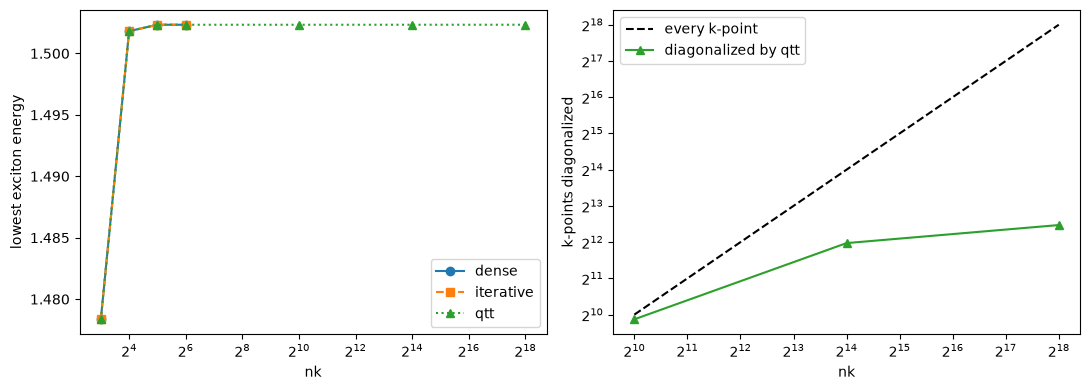

In [2]:
g = geometry.chain().supercell(2) # two-site unit cell
h = g.get_hamiltonian(has_spin=False)
h.add_onsite(lambda r: 0.9*(-1)**int(round(r[0]-0.5))) # staggered potential, opens a gap
V = density_interaction(h,V1=0.8) # first-neighbor repulsion

print("%8s %14s %14s %14s"%("nk","dense","iterative","qtt"))
small = [8,16,32,64]
rows = []
for nk in small:
    e_dense = h.get_bse(V=V,nk=nk,tda=True).get_energies(n=1)[0].real
    e_iter = h.get_bse(V=V,nk=nk,tda=True,solver="iterative",neig=1).get_energies()[0].real
    e_qtt = h.get_bse(V=V,nk=nk,tda=True,solver="qtt",neig=1,tolerance=1e-10).get_energies()[0].real
    rows.append((e_dense,e_iter,e_qtt))
    print("%8d %14.10f %14.10f %14.10f"%(nk,e_dense,e_iter,e_qtt))

print()
print("%8s %14s %12s"%("nk","qtt","k-points"))
big = [1024,16384,262144]
ebig,ndiag = [],[]
for nk in big: # far past the dense solver
    b = h.get_bse(V=V,nk=nk,tda=True,solver="qtt",neig=1,tolerance=1e-6)
    ebig.append(b.get_energies()[0].real) ; ndiag.append(b.pairs.ndiag())
    print("%8d %14.10f %12d"%(nk,ebig[-1],ndiag[-1]))

fig,axs = plt.subplots(1,2,figsize=(11,4))
rows = np.array(rows)
axs[0].plot(small,rows[:,0],"o-",label="dense")
axs[0].plot(small,rows[:,1],"s--",label="iterative")
axs[0].plot(small+big,list(rows[:,2])+ebig,"^:",label="qtt")
axs[0].set_xscale("log",base=2) ; axs[0].legend()
axs[0].set_xlabel("nk") ; axs[0].set_ylabel("lowest exciton energy")
axs[1].plot(big,big,"k--",label="every k-point")
axs[1].plot(big,ndiag,"^-",c="C2",label="diagonalized by qtt")
axs[1].set_xscale("log",base=2) ; axs[1].set_yscale("log",base=2) ; axs[1].legend()
axs[1].set_xlabel("nk") ; axs[1].set_ylabel("k-points diagonalized")
plt.tight_layout()
plt.show()

### The exciton envelope on a fine two-dimensional mesh
In two dimensions the pair basis grows with the square of the mesh and the dense matrix with its
fourth power: on a two-band model a $48\times 48$ mesh is a basis of 2304 pairs, and a
$192\times 192$ one a basis of 36864 pairs, whose dense matrix would take about 20 GB. Let us take a
gapped honeycomb semiconductor with a long-ranged interaction, so that the exciton is shallow and
the mesh matters, and compare the envelope $|A(k)|^2$ of its lowest exciton on a $12\times 12$ mesh
with the dense solver and on a $48\times 48$ mesh with the iterative one. The coarse mesh sees the
exciton only on the K and K' points themselves; the fine one resolves the envelope around each
valley, shown enlarged around one of them in the last panel, and the exciton energy moves
accordingly. The white hexagon is the first Brillouin zone.

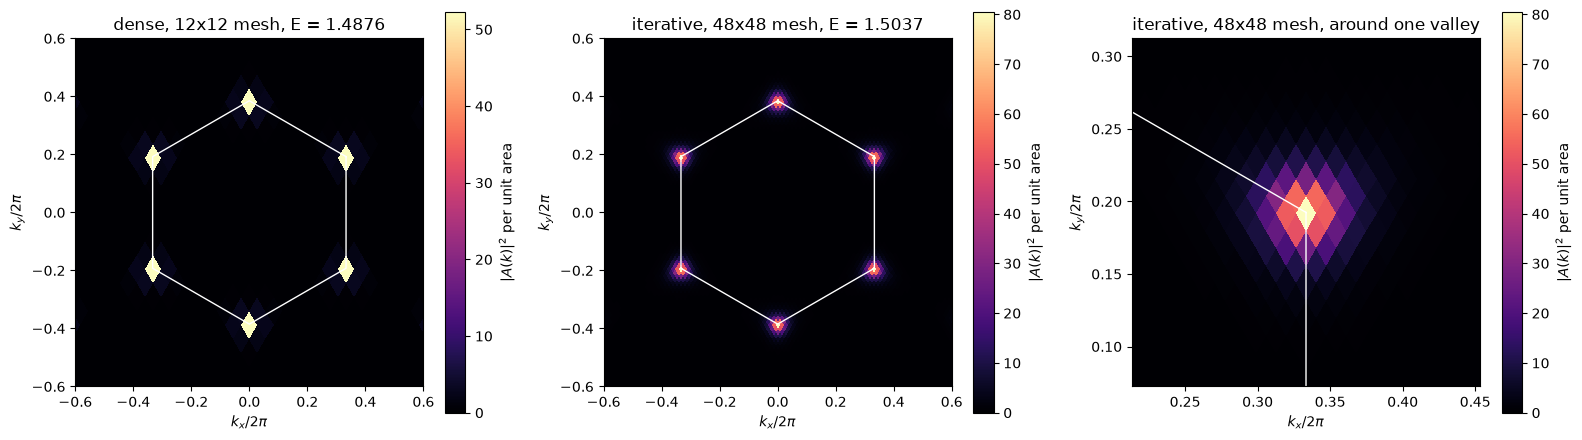

In [3]:
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
h.add_sublattice_imbalance(0.8) # a gapped two-band semiconductor
V = density_interaction(h,V1=0.6,Vr=lambda r1,r2: 0.4/np.sqrt((r1-r2).dot(r1-r2)+0.25)) # long ranged

b1,b2 = np.array(g.b1),np.array(g.b2) # reciprocal lattice vectors
Kc = 2./3.*b1 - 1./3.*b2 # a K point, a corner of the Brillouin zone
angles = np.linspace(0.,2.*np.pi,7) + np.arctan2(Kc[1],Kc[0])
hexagon = np.sqrt(Kc.dot(Kc))*np.array([np.cos(angles),np.sin(angles)])

def envelope(bse,nk): # |A(k)|^2 of the lowest exciton on the (nk,nk) mesh, summed over bands
    A = bse.amplitudes[0] # electron-hole amplitudes of the lowest exciton
    env = np.zeros(nk*nk)
    for m in range(len(A)): env[bse.pairs.kindex[m]] += np.abs(A[m])**2
    return env.reshape((nk,nk))*nk**2 # the mesh is k = (i1,i2)/nk, normalized per unit area

def plot_envelope(ax,env,nk,window): # color map of the envelope in a window of k-space
    for s1 in [-2,-1,0,1]: # repeat the zone to show the valleys around it
        for s2 in [-2,-1,0,1]:
            i1 = (np.arange(nk+1)-0.5)/nk + s1 ; i2 = (np.arange(nk+1)-0.5)/nk + s2
            K1,K2 = np.meshgrid(i1,i2,indexing="ij")
            X = K1*b1[0] + K2*b2[0] ; Y = K1*b1[1] + K2*b2[1]
            im = ax.pcolormesh(X,Y,env,cmap="magma",shading="flat",vmin=0.,vmax=env.max())
    ax.plot(hexagon[0],hexagon[1],c="white",lw=1)
    ax.set_xlim(window[0],window[1]) ; ax.set_ylim(window[2],window[3]) ; ax.set_aspect("equal")
    ax.set_xlabel(r"$k_x/2\pi$") ; ax.set_ylabel(r"$k_y/2\pi$")
    return im

bse12 = h.get_bse(V=V,nk=12,tda=True) # dense solver, coarse mesh
bse48 = h.get_bse(V=V,nk=48,tda=True,solver="iterative",neig=1) # matrix-free, fine mesh
env12,env48 = envelope(bse12,12),envelope(bse48,48)
Kv = hexagon[:,0] # the valley at the first corner of the hexagon
fig,axs = plt.subplots(1,3,figsize=(16,4.5))
panels = [(env12,12,[-0.6,0.6,-0.6,0.6],"dense, 12x12 mesh, E = %.4f"%bse12.get_energies()[0].real),
          (env48,48,[-0.6,0.6,-0.6,0.6],"iterative, 48x48 mesh, E = %.4f"%bse48.get_energies()[0].real),
          (env48,48,[Kv[0]-0.12,Kv[0]+0.12,Kv[1]-0.12,Kv[1]+0.12],"iterative, 48x48 mesh, around one valley")]
for ax,(env,nk,window,title) in zip(axs,panels):
    im = plot_envelope(ax,env,nk,window)
    ax.set_title(title)
    fig.colorbar(im,ax=ax,label=r"$|A(k)|^2$ per unit area")
plt.tight_layout()
plt.show()